In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Project paths
PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


print("Project root:", PROJECT_ROOT)
print("src directory:", SRC_DIR)
print("src exists:", SRC_DIR.exists())

Project root: D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting
src directory: D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\src
src exists: True


In [2]:
## 1. Load Existing Full-History Forecast Results
# Existing forecasting outputs
SA1_PATH = PROJECT_ROOT / "data" / "baseline" / "seasonal_naive" / "SA1_seasonal_naive_test.csv"
NSW1_PATH = PROJECT_ROOT / "data" / "baseline" / "seasonal_naive" / "NSW1_seasonal_naive_test.csv"

print("SA1 exists:", SA1_PATH.exists())
print("NSW1 exists:", NSW1_PATH.exists())

sa1 = pd.read_csv(SA1_PATH, parse_dates=["SETTLEMENTDATE"])
nsw1 = pd.read_csv(NSW1_PATH, parse_dates=["SETTLEMENTDATE"])

sa1["REGION"] = "SA1"
nsw1["REGION"] = "NSW1"

forecast_df = (
    pd.concat([sa1, nsw1], ignore_index=True)
    .sort_values(["REGION", "SETTLEMENTDATE"])
    .reset_index(drop=True)
)

print("Combined shape:", forecast_df.shape)
forecast_df.head()

SA1 exists: True
NSW1 exists: True
Combined shape: (134498, 6)


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D,REGION
0,2020-03-01 00:00:00,7019.06,7146.84,127.78,NaN,NSW1
1,2020-03-01 00:30:00,6843.16,6991.19,148.03,NaN,NSW1
2,2020-03-01 01:00:00,6674.67,6783.37,108.70,NaN,NSW1
3,2020-03-01 01:30:00,6417.07,6503.91,86.84,NaN,NSW1
4,2020-03-01 02:00:00,6221.79,6347.40,125.61,NaN,NSW1


In [3]:
summary = (
    forecast_df.groupby("REGION")
    .agg(
        n_rows=("SETTLEMENTDATE", "size"),
        start_date=("SETTLEMENTDATE", "min"),
        end_date=("SETTLEMENTDATE", "max"),
        missing_actual=("TOTALDEMAND", lambda x: x.isna().sum()),
        missing_prediction=("PREDICTION", lambda x: x.isna().sum()),
    )
)

summary

,n_rows,start_date,end_date,missing_actual,missing_prediction
REGION,,,,,
NSW1,67249,2020-03-01,2024-01-01,0,0
SA1,67249,2020-03-01,2024-01-01,0,0


In [4]:
forecast_df[
    [
        "SETTLEMENTDATE",
        "REGION",
        "TOTALDEMAND",
        "PREDICTION",
        "ABSOLUTE_ERROR",
        "ROLLING_MAE_7D",
    ]
].head(10)

,SETTLEMENTDATE,REGION,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
0,2020-03-01 00:00:00,NSW1,7019.06,7146.84,127.78,NaN
1,2020-03-01 00:30:00,NSW1,6843.16,6991.19,148.03,NaN
2,2020-03-01 01:00:00,NSW1,6674.67,6783.37,108.70,NaN
3,2020-03-01 01:30:00,NSW1,6417.07,6503.91,86.84,NaN
4,2020-03-01 02:00:00,NSW1,6221.79,6347.40,125.61,NaN
5,2020-03-01 02:30:00,NSW1,6169.59,6140.66,28.93,NaN
6,2020-03-01 03:00:00,NSW1,6146.66,6181.97,35.31,NaN
7,2020-03-01 03:30:00,NSW1,6087.75,6122.03,34.28,NaN
8,2020-03-01 04:00:00,NSW1,6051.26,6162.84,111.58,NaN
9,2020-03-01 04:30:00,NSW1,6050.76,6218.91,168.15,NaN


In [5]:
## 2. Chronological Calibration Setup
COVERAGE = 0.90
ALPHA = 1.0 - COVERAGE

SAMPLES_PER_DAY = 48
CALIBRATION_DAYS = 90
CALIBRATION_SIZE = CALIBRATION_DAYS * SAMPLES_PER_DAY

print("Target coverage:", COVERAGE)
print("Calibration days:", CALIBRATION_DAYS)
print("Calibration observations per region:", CALIBRATION_SIZE)

Target coverage: 0.9
Calibration days: 90
Calibration observations per region: 4320


In [6]:
forecast_df["RESIDUAL"] = (
    forecast_df["TOTALDEMAND"] - forecast_df["PREDICTION"]
)

forecast_df["ABS_RESIDUAL"] = forecast_df["RESIDUAL"].abs()

error_check = np.isclose(
    forecast_df["ABS_RESIDUAL"],
    forecast_df["ABSOLUTE_ERROR"],
    rtol=1e-9,
    atol=1e-9,
)

print("ABSOLUTE_ERROR matches calculated residuals:", error_check.all())
print("Maximum difference:",
      (forecast_df["ABS_RESIDUAL"] - forecast_df["ABSOLUTE_ERROR"]).abs().max())

ABSOLUTE_ERROR matches calculated residuals: True
Maximum difference: 1.3642420526593924e-12


In [7]:
calibration_rows = []
evaluation_rows = []

for region, region_df in forecast_df.groupby("REGION"):
    region_df = (
        region_df
        .sort_values("SETTLEMENTDATE")
        .reset_index(drop=True)
    )

    calibration = region_df.iloc[:CALIBRATION_SIZE].copy()
    evaluation = region_df.iloc[CALIBRATION_SIZE:].copy()

    calibration_rows.append(
        {
            "REGION": region,
            "calibration_rows": len(calibration),
            "calibration_start": calibration["SETTLEMENTDATE"].min(),
            "calibration_end": calibration["SETTLEMENTDATE"].max(),
            "evaluation_rows": len(evaluation),
            "evaluation_start": evaluation["SETTLEMENTDATE"].min(),
            "evaluation_end": evaluation["SETTLEMENTDATE"].max(),
        }
    )

split_summary = pd.DataFrame(calibration_rows)

split_summary

,REGION,calibration_rows,calibration_start,calibration_end,evaluation_rows,evaluation_start,evaluation_end
0,NSW1,4320,2020-03-01,2020-05-29 23:30:00,62929,2020-05-30,2024-01-01
1,SA1,4320,2020-03-01,2020-05-29 23:30:00,62929,2020-05-30,2024-01-01


In [8]:
## 3. Static 90% Conformal Prediction Intervals
static_results = []
static_calibration = []

for region, region_df in forecast_df.groupby("REGION"):
    region_df = (
        region_df
        .sort_values("SETTLEMENTDATE")
        .reset_index(drop=True)
    )

    calibration = region_df.iloc[:CALIBRATION_SIZE].copy()
    evaluation = region_df.iloc[CALIBRATION_SIZE:].copy()

    # Frozen-contract style split-conformal quantile
    q = np.quantile(
        calibration["ABS_RESIDUAL"],
        COVERAGE,
    )

    evaluation["LOWER"] = evaluation["PREDICTION"] - q
    evaluation["UPPER"] = evaluation["PREDICTION"] + q

    evaluation["COVERED"] = (
        (evaluation["TOTALDEMAND"] >= evaluation["LOWER"])
        & (evaluation["TOTALDEMAND"] <= evaluation["UPPER"])
    )

    evaluation["INTERVAL_WIDTH"] = (
        evaluation["UPPER"] - evaluation["LOWER"]
    )

    static_results.append(evaluation)

    static_calibration.append(
        {
            "REGION": region,
            "calibration_rows": len(calibration),
            "q_90": q,
        }
    )

static_df = (
    pd.concat(static_results, ignore_index=True)
    .sort_values(["REGION", "SETTLEMENTDATE"])
    .reset_index(drop=True)
)

static_calibration_df = pd.DataFrame(static_calibration)

static_calibration_df

,REGION,calibration_rows,q_90
0,NSW1,4320,885.396
1,SA1,4320,305.164


In [9]:
static_summary = (
    static_df.groupby("REGION")
    .agg(
        n_evaluation=("SETTLEMENTDATE", "size"),
        empirical_coverage=("COVERED", "mean"),
        mean_interval_width=("INTERVAL_WIDTH", "mean"),
        median_interval_width=("INTERVAL_WIDTH", "median"),
        mean_absolute_error=("ABS_RESIDUAL", "mean"),
    )
    .reset_index()
)

static_summary["target_coverage"] = COVERAGE

static_summary

,REGION,n_evaluation,empirical_coverage,mean_interval_width,median_interval_width,mean_absolute_error,target_coverage
0,NSW1,62929,0.858698,1770.792,1770.792,447.966034,0.9
1,SA1,62929,0.850673,610.328,610.328,157.282125,0.9


In [10]:
static_df[
    [
        "SETTLEMENTDATE",
        "REGION",
        "TOTALDEMAND",
        "PREDICTION",
        "LOWER",
        "UPPER",
        "COVERED",
        "INTERVAL_WIDTH",
    ]
].head(10)

,SETTLEMENTDATE,REGION,TOTALDEMAND,PREDICTION,LOWER,UPPER,COVERED,INTERVAL_WIDTH
0,2020-05-30 00:00:00,NSW1,8238.47,8049.23,7163.834,8934.626,True,1770.792
1,2020-05-30 00:30:00,NSW1,8019.58,7921.64,7036.244,8807.036,True,1770.792
2,2020-05-30 01:00:00,NSW1,7874.47,7721.53,6836.134,8606.926,True,1770.792
3,2020-05-30 01:30:00,NSW1,7570.51,7577.91,6692.514,8463.306,True,1770.792
4,2020-05-30 02:00:00,NSW1,7314.04,7354.23,6468.834,8239.626,True,1770.792
5,2020-05-30 02:30:00,NSW1,6971.24,7069.63,6184.234,7955.026,True,1770.792
6,2020-05-30 03:00:00,NSW1,6720.13,6790.31,5904.914,7675.706,True,1770.792
7,2020-05-30 03:30:00,NSW1,6538.97,6625.11,5739.714,7510.506,True,1770.792
8,2020-05-30 04:00:00,NSW1,6470.49,6524.66,5639.264,7410.056,True,1770.792
9,2020-05-30 04:30:00,NSW1,6426.81,6525.42,5640.024,7410.816,True,1770.792


In [11]:
## 4. Static Coverage Through Time
ROLLING_DAYS = 30
ROLLING_WINDOW = ROLLING_DAYS * SAMPLES_PER_DAY

static_df = (
    static_df
    .sort_values(["REGION", "SETTLEMENTDATE"])
    .reset_index(drop=True)
)

static_df["ROLLING_COVERAGE_30D"] = (
    static_df
    .groupby("REGION")["COVERED"]
    .transform(
        lambda x: x.rolling(
            window=ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW
        ).mean()
    )
)

print("Rolling window observations:", ROLLING_WINDOW)

static_df[
    [
        "SETTLEMENTDATE",
        "REGION",
        "COVERED",
        "ROLLING_COVERAGE_30D",
    ]
].dropna().head()

Rolling window observations: 1440


,SETTLEMENTDATE,REGION,COVERED,ROLLING_COVERAGE_30D
1439,2020-06-28 23:30:00,NSW1,True,0.838889
1440,2020-06-29 00:00:00,NSW1,True,0.838889
1441,2020-06-29 00:30:00,NSW1,True,0.838889
1442,2020-06-29 01:00:00,NSW1,True,0.838889
1443,2020-06-29 01:30:00,NSW1,True,0.838889


In [12]:
static_df["YEAR"] = static_df["SETTLEMENTDATE"].dt.year

yearly_static_coverage = (
    static_df.groupby(["REGION", "YEAR"])
    .agg(
        n_observations=("COVERED", "size"),
        empirical_coverage=("COVERED", "mean"),
        mean_interval_width=("INTERVAL_WIDTH", "mean"),
    )
    .reset_index()
)

yearly_static_coverage["target_coverage"] = COVERAGE

yearly_static_coverage

,REGION,YEAR,n_observations,empirical_coverage,mean_interval_width,target_coverage
0,NSW1,2020,10368,0.856385,1770.792,0.9
1,NSW1,2021,17520,0.871632,1770.792,0.9
2,NSW1,2022,17520,0.858562,1770.792,0.9
3,NSW1,2023,17520,0.847260,1770.792,0.9
4,NSW1,2024,1,1.000000,1770.792,0.9
5,SA1,2020,10368,0.849633,610.328,0.9
6,SA1,2021,17520,0.863527,610.328,0.9
7,SA1,2022,17520,0.841381,610.328,0.9
8,SA1,2023,17520,0.847717,610.328,0.9
9,SA1,2024,1,1.000000,610.328,0.9


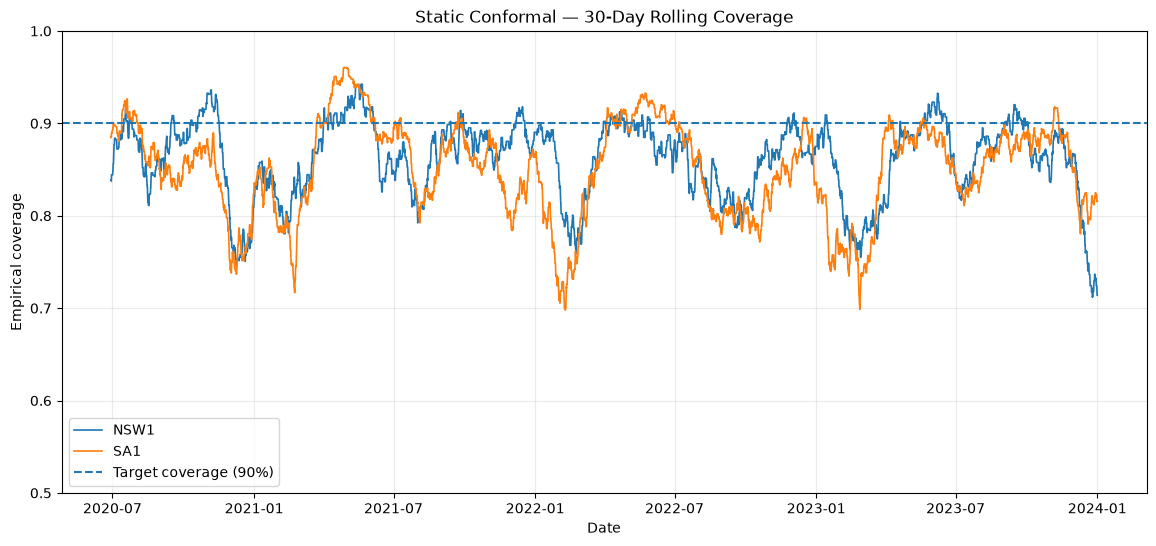

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

for region, region_df in static_df.groupby("REGION"):
    ax.plot(
        region_df["SETTLEMENTDATE"],
        region_df["ROLLING_COVERAGE_30D"],
        label=region,
        linewidth=1.2,
    )

ax.axhline(
    COVERAGE,
    linestyle="--",
    linewidth=1.5,
    label="Target coverage (90%)",
)

ax.set_title("Static Conformal — 30-Day Rolling Coverage")
ax.set_xlabel("Date")
ax.set_ylabel("Empirical coverage")
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(alpha=0.25)

plt.show()

In [14]:
## 5. Adaptive Conformal Prediction Intervals
ADAPTIVE_DAYS = 30
ADAPTIVE_WINDOW = ADAPTIVE_DAYS * SAMPLES_PER_DAY

print("Adaptive calibration days:", ADAPTIVE_DAYS)
print("Adaptive calibration observations:", ADAPTIVE_WINDOW)
print("Target coverage:", COVERAGE)

Adaptive calibration days: 30
Adaptive calibration observations: 1440
Target coverage: 0.9


In [15]:
# Ensure residual columns are available
forecast_df["RESIDUAL"] = (
    forecast_df["TOTALDEMAND"] - forecast_df["PREDICTION"]
)

forecast_df["ABS_RESIDUAL"] = forecast_df["RESIDUAL"].abs()

print("Residual columns ready:")
print(
    forecast_df[
        ["RESIDUAL", "ABS_RESIDUAL"]
    ].head()
)

Residual columns ready:
   RESIDUAL  ABS_RESIDUAL
0   -127.78        127.78
1   -148.03        148.03
2   -108.70        108.70
3    -86.84         86.84
4   -125.61        125.61


In [16]:
adaptive_results = []

for region, region_df in forecast_df.groupby("REGION"):
    region_df = (
        region_df
        .sort_values("SETTLEMENTDATE")
        .reset_index(drop=True)
        .copy()
    )

    # Use only previously observed residuals.
    past_residuals = region_df["ABS_RESIDUAL"].shift(1)

    region_df["ADAPTIVE_Q"] = (
        past_residuals
        .rolling(
            window=ADAPTIVE_WINDOW,
            min_periods=ADAPTIVE_WINDOW,
        )
        .quantile(COVERAGE)
    )

    region_df["ADAPTIVE_LOWER"] = (
        region_df["PREDICTION"] - region_df["ADAPTIVE_Q"]
    )

    region_df["ADAPTIVE_UPPER"] = (
        region_df["PREDICTION"] + region_df["ADAPTIVE_Q"]
    )

    region_df["ADAPTIVE_COVERED"] = (
        (region_df["TOTALDEMAND"] >= region_df["ADAPTIVE_LOWER"])
        & (region_df["TOTALDEMAND"] <= region_df["ADAPTIVE_UPPER"])
    )

    region_df["ADAPTIVE_WIDTH"] = (
        region_df["ADAPTIVE_UPPER"]
        - region_df["ADAPTIVE_LOWER"]
    )

    evaluation = region_df.iloc[CALIBRATION_SIZE:].copy()

    adaptive_results.append(evaluation)

adaptive_df = (
    pd.concat(adaptive_results, ignore_index=True)
    .sort_values(["REGION", "SETTLEMENTDATE"])
    .reset_index(drop=True)
)

adaptive_df[
    [
        "SETTLEMENTDATE",
        "REGION",
        "PREDICTION",
        "ADAPTIVE_Q",
        "ADAPTIVE_LOWER",
        "ADAPTIVE_UPPER",
        "ADAPTIVE_COVERED",
        "ADAPTIVE_WIDTH",
    ]
].head(10)

,SETTLEMENTDATE,REGION,PREDICTION,ADAPTIVE_Q,ADAPTIVE_LOWER,ADAPTIVE_UPPER,ADAPTIVE_COVERED,ADAPTIVE_WIDTH
0,2020-05-30 00:00:00,NSW1,8049.23,929.078,7120.152,8978.308,True,1858.156
1,2020-05-30 00:30:00,NSW1,7921.64,929.078,6992.562,8850.718,True,1858.156
2,2020-05-30 01:00:00,NSW1,7721.53,929.078,6792.452,8650.608,True,1858.156
3,2020-05-30 01:30:00,NSW1,7577.91,929.078,6648.832,8506.988,True,1858.156
4,2020-05-30 02:00:00,NSW1,7354.23,929.078,6425.152,8283.308,True,1858.156
5,2020-05-30 02:30:00,NSW1,7069.63,929.078,6140.552,7998.708,True,1858.156
6,2020-05-30 03:00:00,NSW1,6790.31,929.078,5861.232,7719.388,True,1858.156
7,2020-05-30 03:30:00,NSW1,6625.11,929.078,5696.032,7554.188,True,1858.156
8,2020-05-30 04:00:00,NSW1,6524.66,929.078,5595.582,7453.738,True,1858.156
9,2020-05-30 04:30:00,NSW1,6525.42,929.078,5596.342,7454.498,True,1858.156


In [17]:
print("Evaluation rows:", len(adaptive_df))
print("Missing ADAPTIVE_Q:", adaptive_df["ADAPTIVE_Q"].isna().sum())
print("Missing ADAPTIVE_WIDTH:", adaptive_df["ADAPTIVE_WIDTH"].isna().sum())

Evaluation rows: 125858
Missing ADAPTIVE_Q: 0
Missing ADAPTIVE_WIDTH: 0


In [18]:
adaptive_summary = (
    adaptive_df.groupby("REGION")
    .agg(
        n_evaluation=("SETTLEMENTDATE", "size"),
        empirical_coverage=("ADAPTIVE_COVERED", "mean"),
        mean_interval_width=("ADAPTIVE_WIDTH", "mean"),
        median_interval_width=("ADAPTIVE_WIDTH", "median"),
        mean_absolute_error=("ABS_RESIDUAL", "mean"),
    )
    .reset_index()
)

adaptive_summary["target_coverage"] = COVERAGE

adaptive_summary

,REGION,n_evaluation,empirical_coverage,mean_interval_width,median_interval_width,mean_absolute_error,target_coverage
0,NSW1,62929,0.897519,2126.258463,2055.140667,447.966034,0.9
1,SA1,62929,0.897535,767.120451,726.293667,157.282125,0.9


In [19]:
comparison = (
    static_summary[
        [
            "REGION",
            "empirical_coverage",
            "mean_interval_width",
        ]
    ]
    .rename(
        columns={
            "empirical_coverage": "static_coverage",
            "mean_interval_width": "static_mean_width",
        }
    )
    .merge(
        adaptive_summary[
            [
                "REGION",
                "empirical_coverage",
                "mean_interval_width",
            ]
        ].rename(
            columns={
                "empirical_coverage": "adaptive_coverage",
                "mean_interval_width": "adaptive_mean_width",
            }
        ),
        on="REGION",
    )
)

comparison["target_coverage"] = COVERAGE

comparison["coverage_improvement"] = (
    comparison["adaptive_coverage"]
    - comparison["static_coverage"]
)

comparison["width_change"] = (
    comparison["adaptive_mean_width"]
    - comparison["static_mean_width"]
)

comparison

,REGION,static_coverage,static_mean_width,adaptive_coverage,adaptive_mean_width,target_coverage,coverage_improvement,width_change
0,NSW1,0.858698,1770.792,0.897519,2126.258463,0.9,0.038822,355.466463
1,SA1,0.850673,610.328,0.897535,767.120451,0.9,0.046862,156.792451


In [20]:
## 6. Static vs Adaptive Coverage Through Time
adaptive_df = (
    adaptive_df
    .sort_values(["REGION", "SETTLEMENTDATE"])
    .reset_index(drop=True)
)

adaptive_df["ROLLING_ADAPTIVE_COVERAGE_30D"] = (
    adaptive_df
    .groupby("REGION")["ADAPTIVE_COVERED"]
    .transform(
        lambda x: x.rolling(
            window=ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW,
        ).mean()
    )
)

In [21]:
print(
    "Static rolling coverage available:",
    static_df["ROLLING_COVERAGE_30D"].notna().sum()
)

print(
    "Adaptive rolling coverage available:",
    adaptive_df["ROLLING_ADAPTIVE_COVERAGE_30D"].notna().sum()
)

Static rolling coverage available: 122980
Adaptive rolling coverage available: 122980


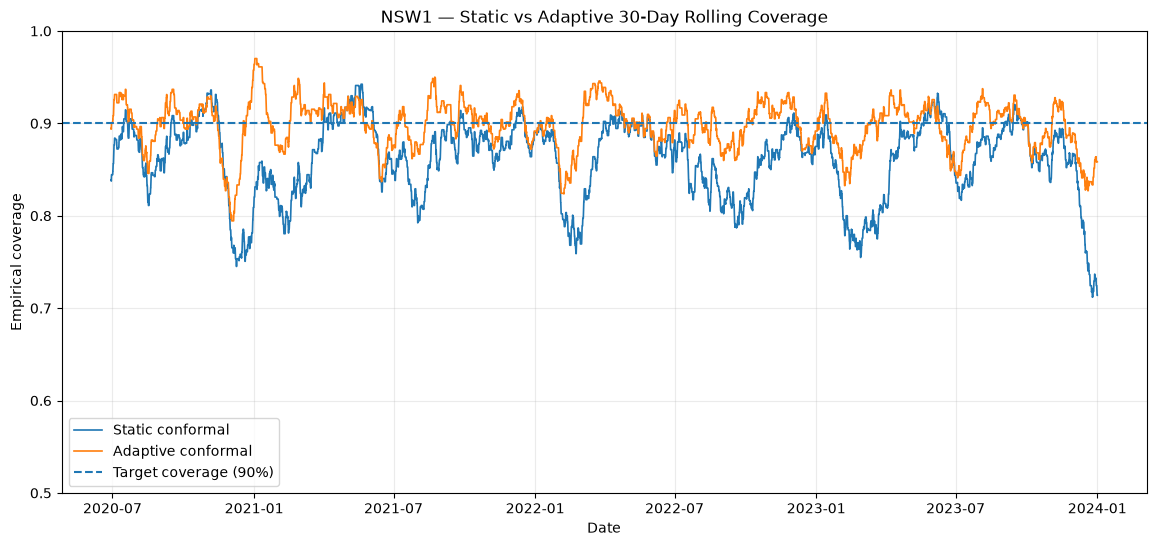

In [22]:
region = "NSW1"

static_region = static_df[
    static_df["REGION"] == region
]

adaptive_region = adaptive_df[
    adaptive_df["REGION"] == region
]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    static_region["SETTLEMENTDATE"],
    static_region["ROLLING_COVERAGE_30D"],
    label="Static conformal",
    linewidth=1.2,
)

ax.plot(
    adaptive_region["SETTLEMENTDATE"],
    adaptive_region["ROLLING_ADAPTIVE_COVERAGE_30D"],
    label="Adaptive conformal",
    linewidth=1.2,
)

ax.axhline(
    COVERAGE,
    linestyle="--",
    linewidth=1.5,
    label="Target coverage (90%)",
)

ax.set_title(
    f"{region} — Static vs Adaptive 30-Day Rolling Coverage"
)
ax.set_xlabel("Date")
ax.set_ylabel("Empirical coverage")
ax.set_ylim(0.5, 1.0)

ax.legend()
ax.grid(alpha=0.25)

plt.show()

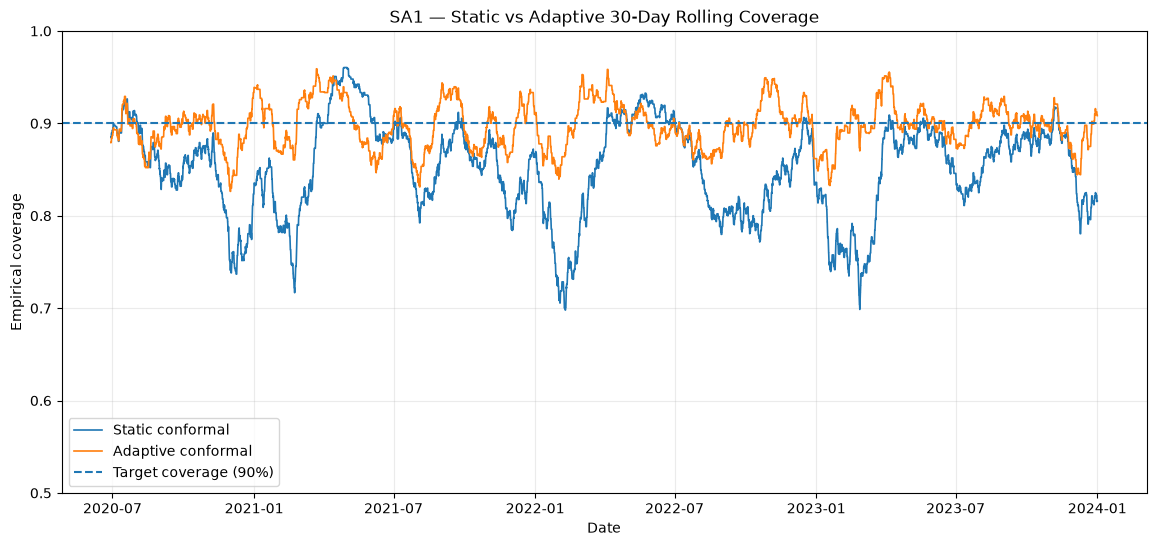

In [23]:
region = "SA1"

static_region = static_df[
    static_df["REGION"] == region
]

adaptive_region = adaptive_df[
    adaptive_df["REGION"] == region
]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    static_region["SETTLEMENTDATE"],
    static_region["ROLLING_COVERAGE_30D"],
    label="Static conformal",
    linewidth=1.2,
)

ax.plot(
    adaptive_region["SETTLEMENTDATE"],
    adaptive_region["ROLLING_ADAPTIVE_COVERAGE_30D"],
    label="Adaptive conformal",
    linewidth=1.2,
)

ax.axhline(
    COVERAGE,
    linestyle="--",
    linewidth=1.5,
    label="Target coverage (90%)",
)

ax.set_title(
    f"{region} — Static vs Adaptive 30-Day Rolling Coverage"
)
ax.set_xlabel("Date")
ax.set_ylabel("Empirical coverage")
ax.set_ylim(0.5, 1.0)

ax.legend()
ax.grid(alpha=0.25)

plt.show()

In [24]:
## 7. Human-Review Escalation Policy
ESCALATION_HISTORY_DAYS = 90
ESCALATION_HISTORY = ESCALATION_HISTORY_DAYS * SAMPLES_PER_DAY
ESCALATION_QUANTILE = 0.90

print("Escalation history days:", ESCALATION_HISTORY_DAYS)
print("Escalation history observations:", ESCALATION_HISTORY)
print("Escalation threshold quantile:", ESCALATION_QUANTILE)

Escalation history days: 90
Escalation history observations: 4320
Escalation threshold quantile: 0.9


In [25]:
escalation_results = []

for region, region_df in forecast_df.groupby("REGION"):
    region_df = (
        region_df
        .sort_values("SETTLEMENTDATE")
        .reset_index(drop=True)
        .copy()
    )

    # Adaptive interval:
    # only previously observed residuals are available.
    past_residuals = region_df["ABS_RESIDUAL"].shift(1)

    region_df["ADAPTIVE_Q"] = (
        past_residuals
        .rolling(
            window=ADAPTIVE_WINDOW,
            min_periods=ADAPTIVE_WINDOW,
        )
        .quantile(COVERAGE)
    )

    region_df["ADAPTIVE_LOWER"] = (
        region_df["PREDICTION"] - region_df["ADAPTIVE_Q"]
    )

    region_df["ADAPTIVE_UPPER"] = (
        region_df["PREDICTION"] + region_df["ADAPTIVE_Q"]
    )

    region_df["ADAPTIVE_WIDTH"] = (
        region_df["ADAPTIVE_UPPER"]
        - region_df["ADAPTIVE_LOWER"]
    )

    region_df["ADAPTIVE_COVERED"] = (
        (region_df["TOTALDEMAND"] >= region_df["ADAPTIVE_LOWER"])
        & (region_df["TOTALDEMAND"] <= region_df["ADAPTIVE_UPPER"])
    )

    # Important:
    # use only interval widths known before the current forecast.
    past_widths = region_df["ADAPTIVE_WIDTH"].shift(1)

    region_df["ESCALATION_THRESHOLD"] = (
        past_widths
        .rolling(
            window=ESCALATION_HISTORY,
            min_periods=ADAPTIVE_WINDOW,
        )
        .quantile(ESCALATION_QUANTILE)
    )

    region_df["ESCALATE"] = (
        region_df["ADAPTIVE_WIDTH"]
        > region_df["ESCALATION_THRESHOLD"]
    )

    # Same evaluation period used previously
    evaluation = region_df.iloc[CALIBRATION_SIZE:].copy()

    escalation_results.append(evaluation)

escalation_df = (
    pd.concat(escalation_results, ignore_index=True)
    .sort_values(["REGION", "SETTLEMENTDATE"])
    .reset_index(drop=True)
)

In [26]:
print(
    "Missing adaptive width:",
    escalation_df["ADAPTIVE_WIDTH"].isna().sum()
)

print(
    "Missing escalation threshold:",
    escalation_df["ESCALATION_THRESHOLD"].isna().sum()
)

print(
    "Total evaluation rows:",
    len(escalation_df)
)

print(
    "Escalated forecasts:",
    escalation_df["ESCALATE"].sum()
)

Missing adaptive width: 0
Missing escalation threshold: 0
Total evaluation rows: 125858
Escalated forecasts: 26990


In [27]:
escalation_summary_rows = []

for region, region_df in escalation_df.groupby("REGION"):

    escalated = region_df[
        region_df["ESCALATE"]
    ]

    automatic = region_df[
        ~region_df["ESCALATE"]
    ]

    escalation_summary_rows.append(
        {
            "REGION": region,
            "n_evaluation": len(region_df),
            "fraction_escalated": region_df["ESCALATE"].mean(),
            "overall_coverage": region_df["ADAPTIVE_COVERED"].mean(),
            "non_escalated_coverage": automatic["ADAPTIVE_COVERED"].mean(),
            "mean_error_escalated": escalated["ABS_RESIDUAL"].mean(),
            "mean_error_non_escalated": automatic["ABS_RESIDUAL"].mean(),
            "mean_width_escalated": escalated["ADAPTIVE_WIDTH"].mean(),
            "mean_width_non_escalated": automatic["ADAPTIVE_WIDTH"].mean(),
        }
    )

escalation_summary = pd.DataFrame(
    escalation_summary_rows
)

escalation_summary

,REGION,n_evaluation,fraction_escalated,overall_coverage,non_escalated_coverage,mean_error_escalated,mean_error_non_escalated,mean_width_escalated,mean_width_non_escalated
0,NSW1,62929,0.209649,0.897519,0.899469,544.789557,422.282570,2582.377223,2005.268139
1,SA1,62929,0.219247,0.897535,0.901571,189.840139,148.139347,885.647067,733.836406


In [28]:
## 8. Escalation Threshold Sweep
ESCALATION_QUANTILES = [
    0.50,
    0.60,
    0.70,
    0.75,
    0.80,
    0.85,
    0.90,
    0.92,
    0.94,
    0.95,
    0.96,
    0.97,
    0.98,
    0.99,
]

print("Threshold quantiles:")
print(ESCALATION_QUANTILES)

Threshold quantiles:
[0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]


In [29]:
sweep_rows = []

for region, region_df in forecast_df.groupby("REGION"):
    region_df = (
        region_df
        .sort_values("SETTLEMENTDATE")
        .reset_index(drop=True)
        .copy()
    )

    # Adaptive interval using only previously observed residuals
    past_residuals = region_df["ABS_RESIDUAL"].shift(1)

    region_df["ADAPTIVE_Q"] = (
        past_residuals
        .rolling(
            window=ADAPTIVE_WINDOW,
            min_periods=ADAPTIVE_WINDOW,
        )
        .quantile(COVERAGE)
    )

    region_df["ADAPTIVE_WIDTH"] = 2 * region_df["ADAPTIVE_Q"]

    region_df["ADAPTIVE_LOWER"] = (
        region_df["PREDICTION"] - region_df["ADAPTIVE_Q"]
    )

    region_df["ADAPTIVE_UPPER"] = (
        region_df["PREDICTION"] + region_df["ADAPTIVE_Q"]
    )

    region_df["ADAPTIVE_COVERED"] = (
        (region_df["TOTALDEMAND"] >= region_df["ADAPTIVE_LOWER"])
        & (region_df["TOTALDEMAND"] <= region_df["ADAPTIVE_UPPER"])
    )

    for threshold_q in ESCALATION_QUANTILES:

        # Current width cannot determine its own escalation threshold
        past_widths = region_df["ADAPTIVE_WIDTH"].shift(1)

        threshold = (
            past_widths
            .rolling(
                window=ESCALATION_HISTORY,
                min_periods=ADAPTIVE_WINDOW,
            )
            .quantile(threshold_q)
        )

        region_eval = region_df.iloc[CALIBRATION_SIZE:].copy()
        threshold_eval = threshold.iloc[CALIBRATION_SIZE:].copy()

        valid = threshold_eval.notna()

        evaluated = region_eval.loc[valid].copy()
        evaluated["THRESHOLD"] = threshold_eval.loc[valid].to_numpy()

        evaluated["ESCALATE_SWEEP"] = (
            evaluated["ADAPTIVE_WIDTH"]
            > evaluated["THRESHOLD"]
        )

        automatic = evaluated[
            ~evaluated["ESCALATE_SWEEP"]
        ]

        sweep_rows.append(
            {
                "REGION": region,
                "threshold_quantile": threshold_q,
                "n_evaluated": len(evaluated),
                "fraction_escalated": evaluated["ESCALATE_SWEEP"].mean(),
                "non_escalated_coverage": automatic["ADAPTIVE_COVERED"].mean(),
                "n_non_escalated": len(automatic),
                "mean_error_non_escalated": automatic["ABS_RESIDUAL"].mean(),
            }
        )

threshold_sweep = pd.DataFrame(sweep_rows)

threshold_sweep[
    [
        "REGION",
        "threshold_quantile",
        "n_evaluated",
        "fraction_escalated",
        "non_escalated_coverage",
    ]
]

,REGION,threshold_quantile,n_evaluated,fraction_escalated,non_escalated_coverage
0,NSW1,0.50,62929,0.504759,0.900786
1,NSW1,0.60,62929,0.432344,0.898606
2,NSW1,0.70,62929,0.360724,0.899873
3,NSW1,0.75,62929,0.327989,0.899572
4,NSW1,0.80,62929,0.288818,0.900232
5,NSW1,0.85,62929,0.246850,0.899610
6,NSW1,0.90,62929,0.207520,0.899679
7,NSW1,0.92,62929,0.186051,0.900197
8,NSW1,0.94,62929,0.158194,0.900498
9,NSW1,0.95,62929,0.139824,0.901108


In [30]:
print("Rows in sweep:", len(threshold_sweep))

threshold_sweep[
    [
        "REGION",
        "threshold_quantile",
        "fraction_escalated",
        "non_escalated_coverage",
    ]
]

Rows in sweep: 28


,REGION,threshold_quantile,fraction_escalated,non_escalated_coverage
0,NSW1,0.50,0.504759,0.900786
1,NSW1,0.60,0.432344,0.898606
2,NSW1,0.70,0.360724,0.899873
3,NSW1,0.75,0.327989,0.899572
4,NSW1,0.80,0.288818,0.900232
5,NSW1,0.85,0.246850,0.899610
6,NSW1,0.90,0.207520,0.899679
7,NSW1,0.92,0.186051,0.900197
8,NSW1,0.94,0.158194,0.900498
9,NSW1,0.95,0.139824,0.901108


In [31]:
threshold_sweep.groupby("REGION")["n_evaluated"].unique()

REGION
NSW1    [62929]
SA1     [62929]
Name: n_evaluated, dtype: object

In [32]:
print("Rows in sweep:", len(threshold_sweep))
threshold_sweep

Rows in sweep: 28


,REGION,threshold_quantile,n_evaluated,fraction_escalated,non_escalated_coverage,n_non_escalated,mean_error_non_escalated
0,NSW1,0.50,62929,0.504759,0.900786,31165,392.952042
1,NSW1,0.60,62929,0.432344,0.898606,35722,404.492965
2,NSW1,0.70,62929,0.360724,0.899873,40229,410.423770
3,NSW1,0.75,62929,0.327989,0.899572,42289,412.086883
4,NSW1,0.80,62929,0.288818,0.900232,44754,414.497705
5,NSW1,0.85,62929,0.246850,0.899610,47395,418.887867
6,NSW1,0.90,62929,0.207520,0.899679,49870,422.001838
7,NSW1,0.92,62929,0.186051,0.900197,51221,422.613336
8,NSW1,0.94,62929,0.158194,0.900498,52974,425.353310
9,NSW1,0.95,62929,0.139824,0.901108,54130,426.719473


In [33]:
## 9. Minimum Human-Review Rate for Target Coverage
eligible_thresholds = threshold_sweep[
    threshold_sweep["non_escalated_coverage"] >= COVERAGE
].copy()

minimum_review_rows = []

for region, region_df in eligible_thresholds.groupby("REGION"):
    best = region_df.loc[
        region_df["fraction_escalated"].idxmin()
    ]

    minimum_review_rows.append(
        {
            "REGION": region,
            "threshold_quantile": best["threshold_quantile"],
            "fraction_escalated": best["fraction_escalated"],
            "non_escalated_coverage": best["non_escalated_coverage"],
            "n_non_escalated": int(best["n_non_escalated"]),
        }
    )

minimum_review = pd.DataFrame(minimum_review_rows)

minimum_review

,REGION,threshold_quantile,fraction_escalated,non_escalated_coverage,n_non_escalated
0,NSW1,0.99,0.056715,0.902763,59360
1,SA1,0.99,0.072526,0.902973,58365


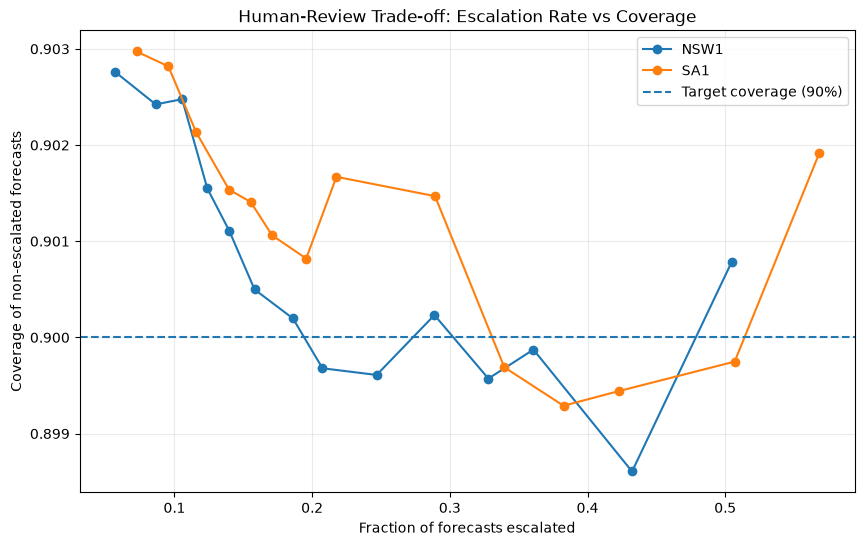

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

for region, region_df in threshold_sweep.groupby("REGION"):
    ordered = region_df.sort_values("fraction_escalated")

    ax.plot(
        ordered["fraction_escalated"],
        ordered["non_escalated_coverage"],
        marker="o",
        label=region,
    )

ax.axhline(
    COVERAGE,
    linestyle="--",
    linewidth=1.5,
    label="Target coverage (90%)",
)

ax.set_title("Human-Review Trade-off: Escalation Rate vs Coverage")
ax.set_xlabel("Fraction of forecasts escalated")
ax.set_ylabel("Coverage of non-escalated forecasts")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

In [35]:
## 10. Fine Search Near the Minimum Review Boundary
FINE_ESCALATION_QUANTILES = np.linspace(
    0.990,
    0.999,
    10,
)

FINE_ESCALATION_QUANTILES

array([0.99 , 0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998,
       0.999])

In [36]:
fine_sweep_rows = []

for region, region_df in forecast_df.groupby("REGION"):
    region_df = (
        region_df
        .sort_values("SETTLEMENTDATE")
        .reset_index(drop=True)
        .copy()
    )

    # Adaptive interval from previously observed residuals only
    past_residuals = region_df["ABS_RESIDUAL"].shift(1)

    region_df["ADAPTIVE_Q"] = (
        past_residuals
        .rolling(
            window=ADAPTIVE_WINDOW,
            min_periods=ADAPTIVE_WINDOW,
        )
        .quantile(COVERAGE)
    )

    region_df["ADAPTIVE_WIDTH"] = 2 * region_df["ADAPTIVE_Q"]

    region_df["ADAPTIVE_LOWER"] = (
        region_df["PREDICTION"] - region_df["ADAPTIVE_Q"]
    )

    region_df["ADAPTIVE_UPPER"] = (
        region_df["PREDICTION"] + region_df["ADAPTIVE_Q"]
    )

    region_df["ADAPTIVE_COVERED"] = (
        (region_df["TOTALDEMAND"] >= region_df["ADAPTIVE_LOWER"])
        & (region_df["TOTALDEMAND"] <= region_df["ADAPTIVE_UPPER"])
    )

    past_widths = region_df["ADAPTIVE_WIDTH"].shift(1)

    for threshold_q in FINE_ESCALATION_QUANTILES:

        threshold = (
            past_widths
            .rolling(
                window=ESCALATION_HISTORY,
                min_periods=ADAPTIVE_WINDOW,
            )
            .quantile(threshold_q)
        )

        region_eval = region_df.iloc[CALIBRATION_SIZE:].copy()
        threshold_eval = threshold.iloc[CALIBRATION_SIZE:].copy()

        valid = threshold_eval.notna()

        evaluated = region_eval.loc[valid].copy()
        evaluated["THRESHOLD"] = threshold_eval.loc[valid].to_numpy()

        evaluated["ESCALATE"] = (
            evaluated["ADAPTIVE_WIDTH"]
            > evaluated["THRESHOLD"]
        )

        automatic = evaluated[~evaluated["ESCALATE"]]

        fine_sweep_rows.append(
            {
                "REGION": region,
                "threshold_quantile": threshold_q,
                "fraction_escalated": evaluated["ESCALATE"].mean(),
                "non_escalated_coverage": automatic["ADAPTIVE_COVERED"].mean(),
                "n_non_escalated": len(automatic),
            }
        )

fine_threshold_sweep = pd.DataFrame(fine_sweep_rows)

fine_threshold_sweep

,REGION,threshold_quantile,fraction_escalated,non_escalated_coverage,n_non_escalated
0,NSW1,0.990,0.056715,0.902763,59360
1,NSW1,0.991,0.051757,0.902919,59672
2,NSW1,0.992,0.048245,0.903027,59893
3,NSW1,0.993,0.044479,0.903210,60130
4,NSW1,0.994,0.039711,0.903508,60430
5,NSW1,0.995,0.035627,0.903851,60687
6,NSW1,0.996,0.031242,0.904204,60963
7,NSW1,0.997,0.025696,0.904684,61312
8,NSW1,0.998,0.021151,0.905111,61598
9,NSW1,0.999,0.016606,0.905452,61884


In [37]:
final_candidates = (
    fine_threshold_sweep[
        fine_threshold_sweep["non_escalated_coverage"] >= COVERAGE
    ]
    .sort_values(
        ["REGION", "fraction_escalated"]
    )
)

final_operating_point = (
    final_candidates
    .groupby("REGION", as_index=False)
    .first()
)

final_operating_point

,REGION,threshold_quantile,fraction_escalated,non_escalated_coverage,n_non_escalated
0,NSW1,0.999,0.016606,0.905452,61884
1,SA1,0.999,0.020309,0.905727,61651


In [38]:
## 11. Final ARM C Results
final_summary = (
    comparison[
        [
            "REGION",
            "static_coverage",
            "static_mean_width",
            "adaptive_coverage",
            "adaptive_mean_width",
            "coverage_improvement",
        ]
    ]
    .merge(
        final_operating_point[
            [
                "REGION",
                "threshold_quantile",
                "fraction_escalated",
                "non_escalated_coverage",
            ]
        ],
        on="REGION",
    )
)

final_summary

,REGION,static_coverage,static_mean_width,adaptive_coverage,adaptive_mean_width,coverage_improvement,threshold_quantile,fraction_escalated,non_escalated_coverage
0,NSW1,0.858698,1770.792,0.897519,2126.258463,0.038822,0.999,0.016606,0.905452
1,SA1,0.850673,610.328,0.897535,767.120451,0.046862,0.999,0.020309,0.905727


In [39]:
## 11. Final ARM C Results
final_summary = (
    comparison[
        [
            "REGION",
            "static_coverage",
            "static_mean_width",
            "adaptive_coverage",
            "adaptive_mean_width",
            "coverage_improvement",
        ]
    ]
    .merge(
        final_operating_point[
            [
                "REGION",
                "threshold_quantile",
                "fraction_escalated",
                "non_escalated_coverage",
            ]
        ],
        on="REGION",
        how="left",
    )
)

final_summary

,REGION,static_coverage,static_mean_width,adaptive_coverage,adaptive_mean_width,coverage_improvement,threshold_quantile,fraction_escalated,non_escalated_coverage
0,NSW1,0.858698,1770.792,0.897519,2126.258463,0.038822,0.999,0.016606,0.905452
1,SA1,0.850673,610.328,0.897535,767.120451,0.046862,0.999,0.020309,0.905727


In [40]:
final_summary_display = final_summary.copy()

percent_cols = [
    "static_coverage",
    "adaptive_coverage",
    "coverage_improvement",
    "fraction_escalated",
    "non_escalated_coverage",
]

for col in percent_cols:
    final_summary_display[col] = (
        final_summary_display[col] * 100
    )

final_summary_display.style.format(
    {
        "static_coverage": "{:.2f}%",
        "static_mean_width": "{:.2f}",
        "adaptive_coverage": "{:.2f}%",
        "adaptive_mean_width": "{:.2f}",
        "coverage_improvement": "{:.2f}%",
        "threshold_quantile": "{:.3f}",
        "fraction_escalated": "{:.2f}%",
        "non_escalated_coverage": "{:.2f}%",
    }
)

,REGION,static_coverage,static_mean_width,adaptive_coverage,adaptive_mean_width,coverage_improvement,threshold_quantile,fraction_escalated,non_escalated_coverage
0,NSW1,85.87%,1770.79,89.75%,2126.26,3.88%,0.999,1.66%,90.55%
1,SA1,85.07%,610.33,89.75%,767.12,4.69%,0.999,2.03%,90.57%


In [41]:
## 12. Save Final ARM C Outputs
from pathlib import Path

ARM_C_FIG_DIR = PROJECT_ROOT / "results" / "figures"
ARM_C_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Figure output directory:", ARM_C_FIG_DIR)

Figure output directory: D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\results\figures


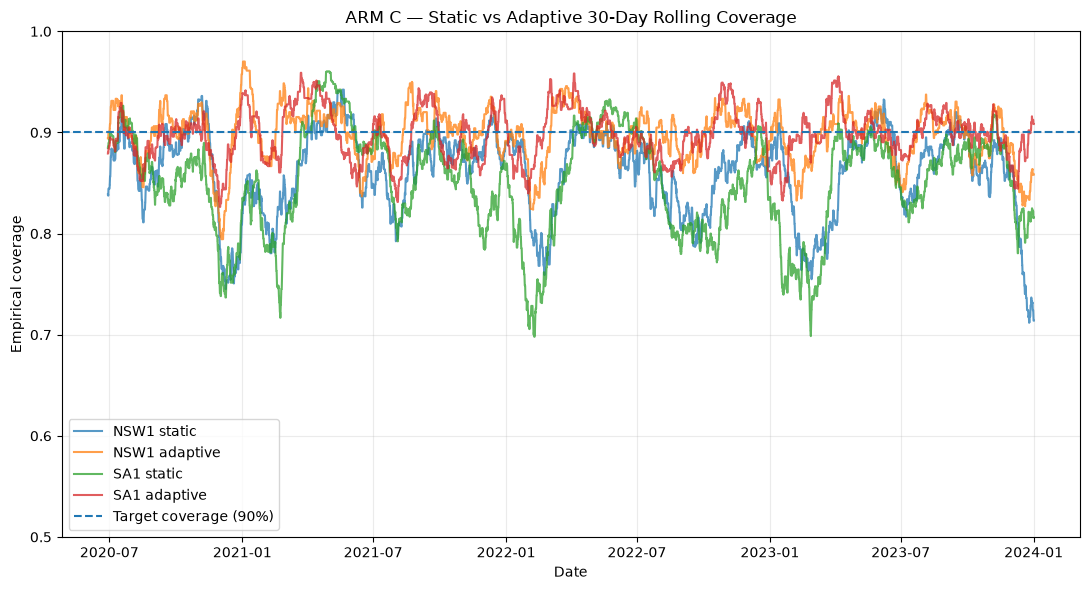

Saved: D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\results\figures\arm_c_static_vs_adaptive_coverage.png


In [42]:
fig, ax = plt.subplots(figsize=(11, 6))

for region in ["NSW1", "SA1"]:
    static_region = static_df[static_df["REGION"] == region]
    adaptive_region = adaptive_df[adaptive_df["REGION"] == region]

    ax.plot(
        static_region["SETTLEMENTDATE"],
        static_region["ROLLING_COVERAGE_30D"],
        alpha=0.75,
        label=f"{region} static",
    )

    ax.plot(
        adaptive_region["SETTLEMENTDATE"],
        adaptive_region["ROLLING_ADAPTIVE_COVERAGE_30D"],
        alpha=0.75,
        label=f"{region} adaptive",
    )

ax.axhline(
    COVERAGE,
    linestyle="--",
    linewidth=1.5,
    label="Target coverage (90%)",
)

ax.set_title("ARM C — Static vs Adaptive 30-Day Rolling Coverage")
ax.set_xlabel("Date")
ax.set_ylabel("Empirical coverage")
ax.set_ylim(0.5, 1.0)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

coverage_path = ARM_C_FIG_DIR / "arm_c_static_vs_adaptive_coverage.png"
fig.savefig(coverage_path, dpi=160, bbox_inches="tight")

plt.show()

print("Saved:", coverage_path)

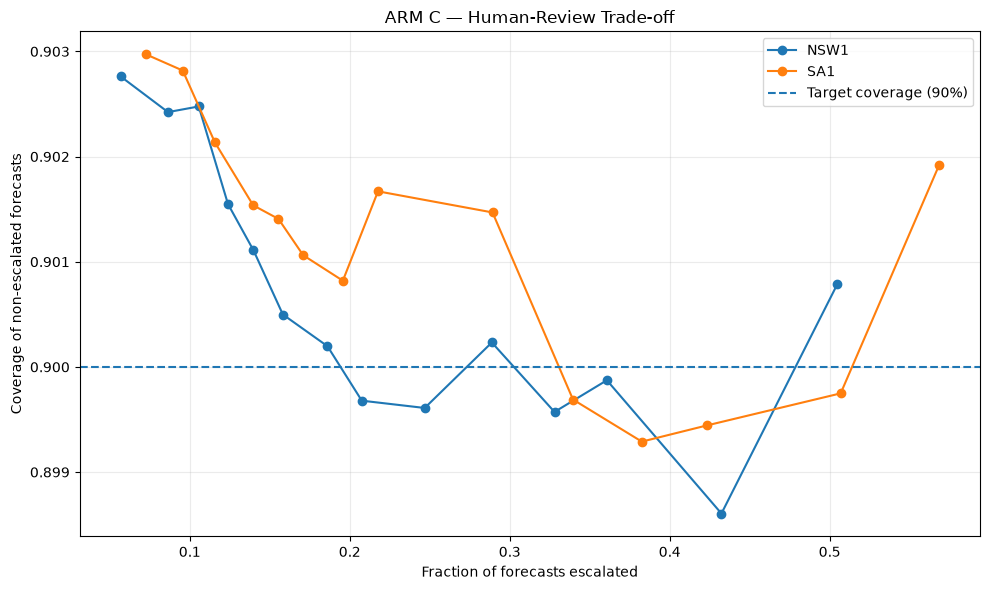

Saved: D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\results\figures\arm_c_human_review_tradeoff.png


In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

for region, region_df in threshold_sweep.groupby("REGION"):
    ordered = region_df.sort_values("fraction_escalated")

    ax.plot(
        ordered["fraction_escalated"],
        ordered["non_escalated_coverage"],
        marker="o",
        label=region,
    )

ax.axhline(
    COVERAGE,
    linestyle="--",
    linewidth=1.5,
    label="Target coverage (90%)",
)

ax.set_title("ARM C — Human-Review Trade-off")
ax.set_xlabel("Fraction of forecasts escalated")
ax.set_ylabel("Coverage of non-escalated forecasts")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

tradeoff_path = ARM_C_FIG_DIR / "arm_c_human_review_tradeoff.png"
fig.savefig(tradeoff_path, dpi=160, bbox_inches="tight")

plt.show()

print("Saved:", tradeoff_path)

In [44]:
ARM_C_TABLE_DIR = PROJECT_ROOT / "results" / "tables"
ARM_C_TABLE_DIR.mkdir(parents=True, exist_ok=True)

summary_path = ARM_C_TABLE_DIR / "arm_c_full_history_summary.csv"

final_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\results\tables\arm_c_full_history_summary.csv


In [45]:
print(coverage_path.exists(), coverage_path)
print(tradeoff_path.exists(), tradeoff_path)
print(summary_path.exists(), summary_path)

True D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\results\figures\arm_c_static_vs_adaptive_coverage.png
True D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\results\figures\arm_c_human_review_tradeoff.png
True D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\results\tables\arm_c_full_history_summary.csv


## 13. Findings and Interpretation

The static conformal intervals under-covered the nominal 90% target in both
regions. Static empirical coverage was approximately 85.87% for NSW1 and
85.07% for SA1.

The adaptive conformal approach improved coverage to approximately 89.75% in
both regions. This represents an improvement of about 3.88 percentage points
for NSW1 and 4.69 percentage points for SA1.

The rolling-coverage analysis also shows that adaptive intervals generally
remain closer to the 90% target over time than the static intervals, although
periods of under-coverage still occur.

The human-review escalation policy was then evaluated using adaptive interval
width as an uncertainty signal. Forecasts with larger uncertainty were more
likely to be escalated for review.

Within the evaluated threshold grid, the 0.999 width-quantile threshold
produced the lowest observed review rate while maintaining at least 90%
coverage among non-escalated forecasts.

Under this operating point:

- NSW1 escalated approximately 1.66% of forecasts, while the remaining
  forecasts achieved approximately 90.55% coverage.
- SA1 escalated approximately 2.03% of forecasts, while the remaining
  forecasts achieved approximately 90.57% coverage.

These results suggest that a small proportion of high-uncertainty forecasts
can be routed for human review while allowing the majority of forecasts to
remain automatically processed with coverage close to or above the target.

## 14. Limitations

The selected escalation threshold is not claimed to be globally optimal. It
is the best operating point observed within the evaluated threshold grid.

The analysis is based on the existing NSW1 and SA1 forecast outputs and does
not retrain the underlying forecasting models.

The adaptive uncertainty estimates use only previously observed residuals to
avoid future information leakage.